In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# Load merged hourly dataset
#df = pd.read_csv("../../data_cleaned/merged/02_4_clean_data_daily_mean.csv")
df = pd.read_csv("../../data_cleaned/merged/02_4_clean_data.csv")
df = df[df["hour"] == 3].copy()
# Convert timestamp columns to datetime
df["period_start_utc"] = pd.to_datetime(df["period_start_utc"], utc=True, errors="coerce")
df["period_end_utc"] = pd.to_datetime(df["period_end_utc"], utc=True, errors="coerce")

# Optional: convert date column if needed
df["date"] = pd.to_datetime(df["date"], errors="coerce")
# Basic cleaning and sorting
# df["gen_forecast_da"] = pd.to_numeric(df["gen_forecast_da"], errors="coerce")
df = df.sort_values("period_start_utc")

df.head(4)

,date,year,month,day,dayofyear,hour,dayofweek,price,period_start_utc,period_end_utc,...,res_sum_da,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas
3,2019-01-01,2019,1,1,1,3,1,-7.41,2019-01-01 03:00:00+00:00,2019-01-01 04:00:00+00:00,...,30359.5675,0.000000,1.000000,0.707107,0.707107,0.781831,0.623490,1,holiday,22.280
27,2019-01-02,2019,1,2,2,3,2,-48.93,2019-01-02 03:00:00+00:00,2019-01-02 04:00:00+00:00,...,37107.2750,0.017202,0.999852,0.707107,0.707107,0.974928,-0.222521,0,weekday,22.280
51,2019-01-03,2019,1,3,3,3,3,43.88,2019-01-03 03:00:00+00:00,2019-01-03 04:00:00+00:00,...,15754.1250,0.034398,0.999408,0.707107,0.707107,0.433884,-0.900969,0,weekday,22.215
75,2019-01-04,2019,1,4,4,3,4,47.00,2019-01-04 03:00:00+00:00,2019-01-04 04:00:00+00:00,...,14458.7225,0.051584,0.998669,0.707107,0.707107,-0.433884,-0.900969,0,weekday,22.845


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2557 entries, 3 to 61347
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   date              2557 non-null   datetime64[ns]     
 1   year              2557 non-null   int64              
 2   month             2557 non-null   int64              
 3   day               2557 non-null   int64              
 4   dayofyear         2557 non-null   int64              
 5   hour              2557 non-null   int64              
 6   dayofweek         2557 non-null   int64              
 7   price             2557 non-null   float64            
 8   period_start_utc  2557 non-null   datetime64[ns, UTC]
 9   period_end_utc    2557 non-null   datetime64[ns, UTC]
 10  load_forecast_da  2557 non-null   float64            
 11  off_wind_da       2557 non-null   float64            
 12  on_wind_da        2557 non-null   float64            
 13  solar_d

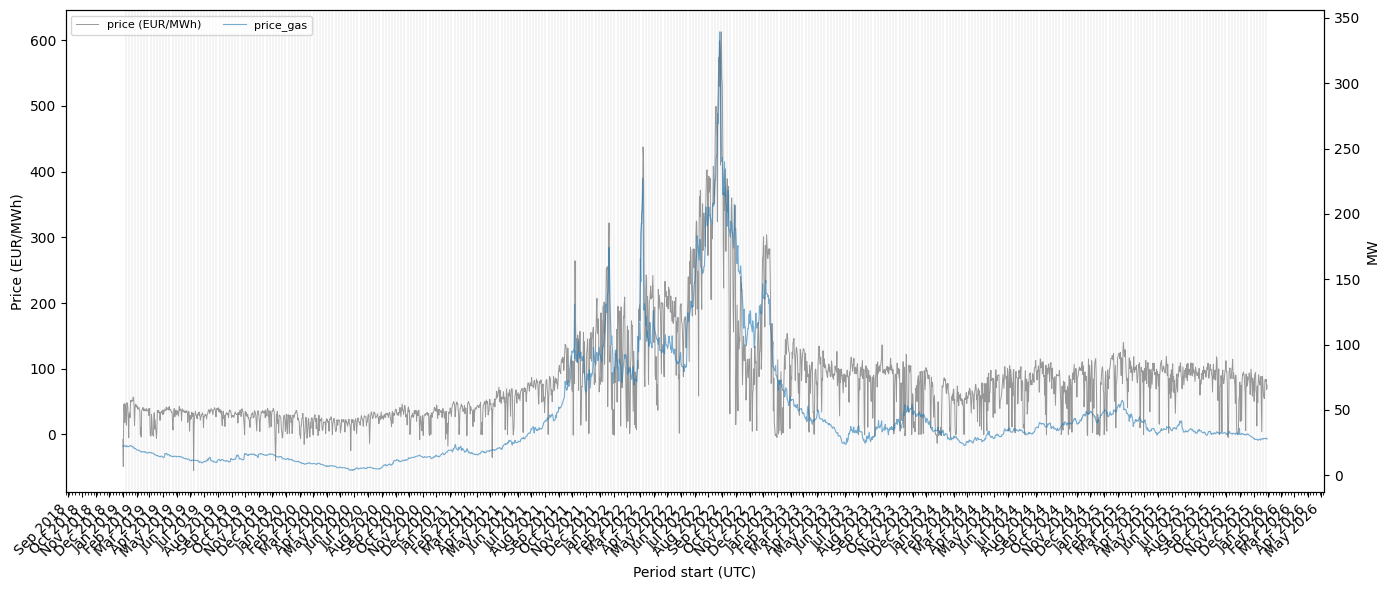

In [4]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

feature_cols = ["price_gas"] #, ""load_forecast_da", "res_sum_da"]

df_plot = df.copy()
df_plot["period_start_utc"] = pd.to_datetime(df_plot["period_start_utc"], errors="coerce")
years = [2019,2020,2021,2022,2023,2024,2025]
df_plot = df_plot[df_plot["year"].isin(years)].copy()
df_plot = df_plot.sort_values("period_start_utc")

df_daily = (
    df_plot
    .set_index("period_start_utc")[["price"] + feature_cols]
    .resample("D")
    .mean()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df_daily["period_start_utc"], df_daily["price"], color="black", alpha=0.4, linewidth=0.7, label="price (EUR/MWh)")
ax1.set_ylabel("Price (EUR/MWh)")
ax1.set_xlabel("Period start (UTC)")

ax2 = ax1.twinx()
for col in feature_cols:
    ax2.plot(df_daily["period_start_utc"], df_daily[col], alpha=0.6, linewidth=0.8, label=col)
ax2.set_ylabel("MW")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", ncol=2, fontsize=8)

# Better month labels + weekly lines
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

for dt in pd.date_range(
    df_daily["period_start_utc"].min(),
    df_daily["period_start_utc"].max(),
    freq="W-MON"
):
    ax1.axvline(dt, color="gray", linewidth=0.3, alpha=0.4)

plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_prices_and_da_features(
    df,
    feature_cols_da=None,
    years=None,
    datetime_col="period_start_utc",
    resample_freq="D",
    figsize=(15, 9),
):
    if feature_cols_da is None:
        feature_cols_da = ["load_forecast_da", "res_sum_da"]
    if years is None:
        years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

    df_plot = df.copy()
    df_plot[datetime_col] = pd.to_datetime(df_plot[datetime_col], errors="coerce")
    df_plot = df_plot[df_plot[datetime_col].notna()].sort_values(datetime_col)

    if years is not None:
        df_plot = df_plot[df_plot[datetime_col].dt.year.isin(years)]

    cols = ["price", "price_gas"] + feature_cols_da
    cols = [c for c in cols if c in df_plot.columns]

    df_daily = (
        df_plot
        .set_index(datetime_col)[cols]
        .resample(resample_freq)
        .mean()
        .reset_index()
    )

    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, figsize=figsize, sharex=True, gridspec_kw={"height_ratios": [1, 1]}
    )

    # Top: prices
    if "price" in df_daily.columns:
        ax_top.plot(df_daily[datetime_col], df_daily["price"], color="black", linewidth=1.0, alpha=0.8, label="price (EUR/MWh)")
    if "price_gas" in df_daily.columns:
        ax_top.plot(df_daily[datetime_col], df_daily["price_gas"], color="tab:blue", linewidth=1.0, alpha=0.8, label="price_gas")
    ax_top.set_ylabel("EUR/MWh")
    ax_top.set_title("Prices")
    ax_top.legend(loc="upper left", fontsize=9)

    # Bottom: DA features
    for col in feature_cols_da:
        if col in df_daily.columns:
            ax_bottom.plot(df_daily[datetime_col], df_daily[col], linewidth=1.0, alpha=0.85, label=col)
    ax_bottom.set_ylabel("MW")
    ax_bottom.set_title("DA Features")
    ax_bottom.set_xlabel("Period start (UTC)")
    ax_bottom.legend(loc="upper left", fontsize=9)

    # X-axis labels yearly
    ax_bottom.xaxis.set_major_locator(mdates.YearLocator())
    ax_bottom.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax_bottom.get_xticklabels(), rotation=0, ha="center")

    # Monthly vertical lines
    month_starts = pd.date_range(df_daily[datetime_col].min(), df_daily[datetime_col].max(), freq="MS")
    for dt in month_starts:
        ax_top.axvline(dt, color="gray", linewidth=0.35, alpha=0.35)
        ax_bottom.axvline(dt, color="gray", linewidth=0.35, alpha=0.35)

    plt.tight_layout()
    plt.show()
    return df_daily


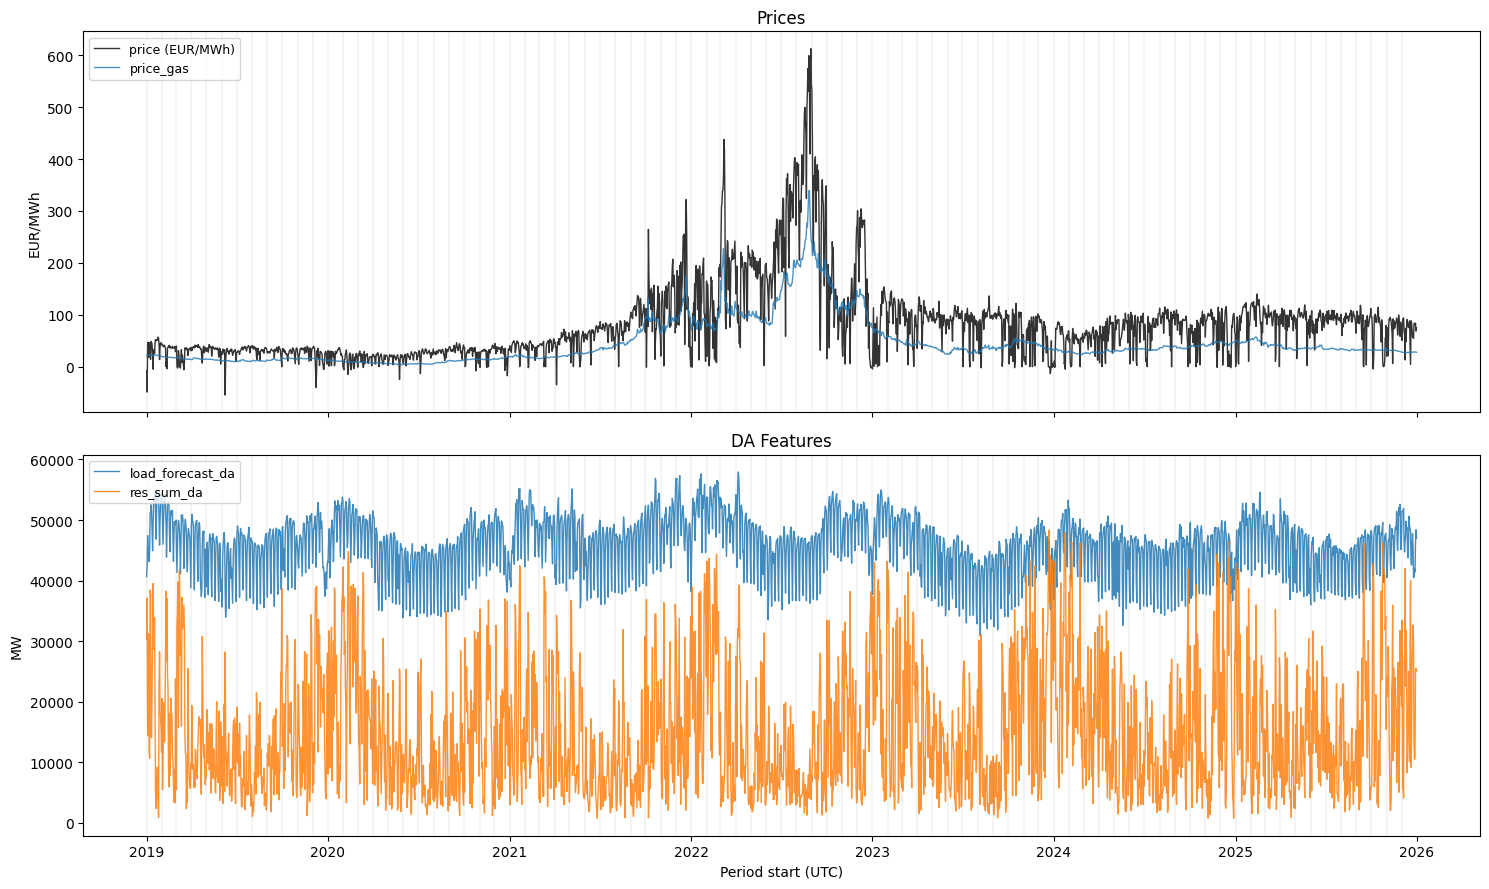

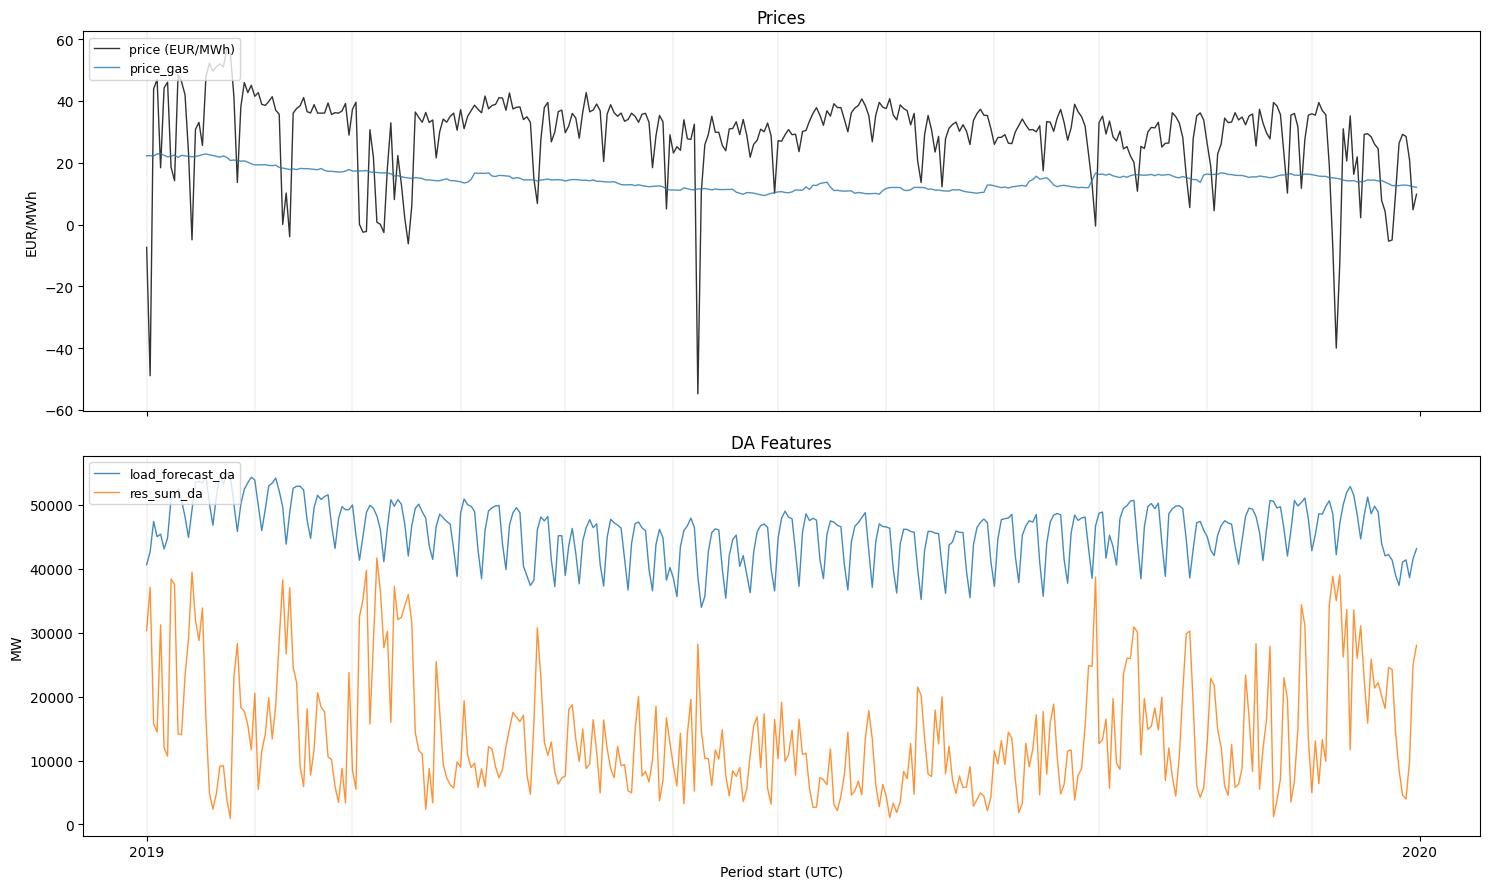

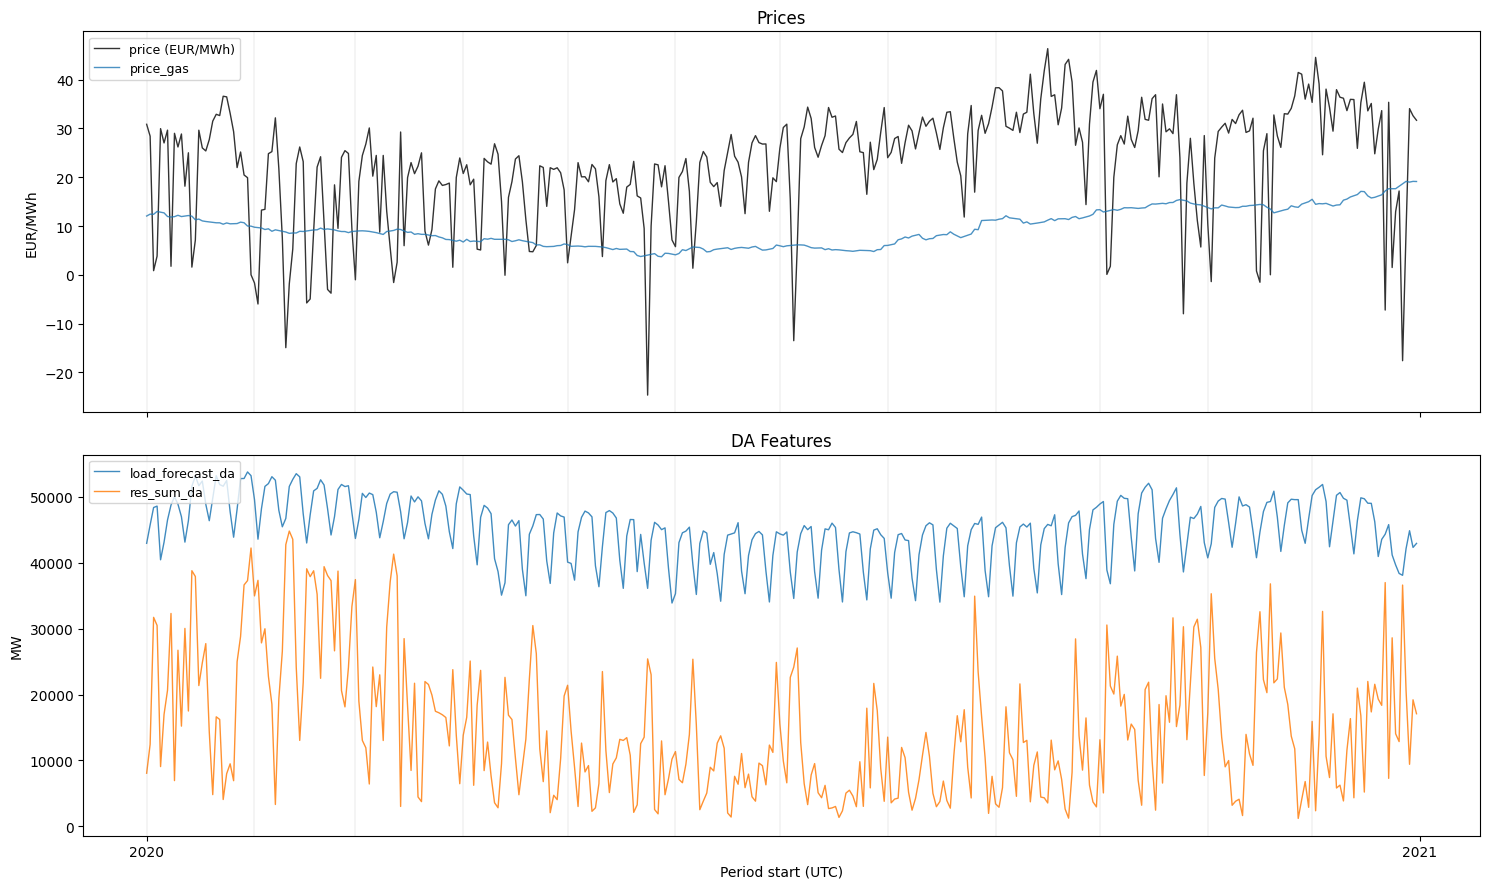

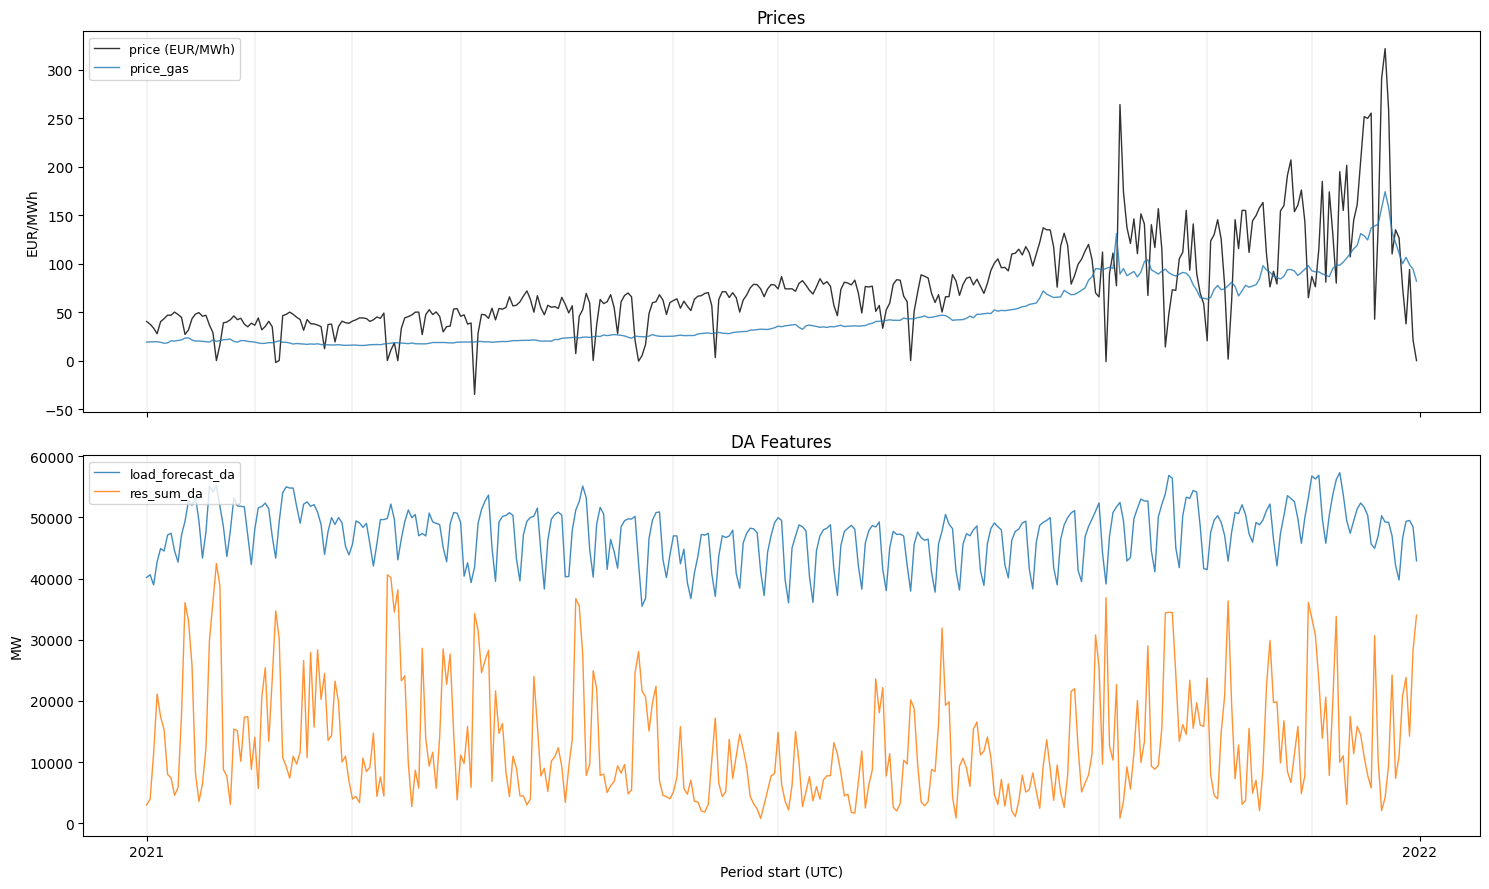

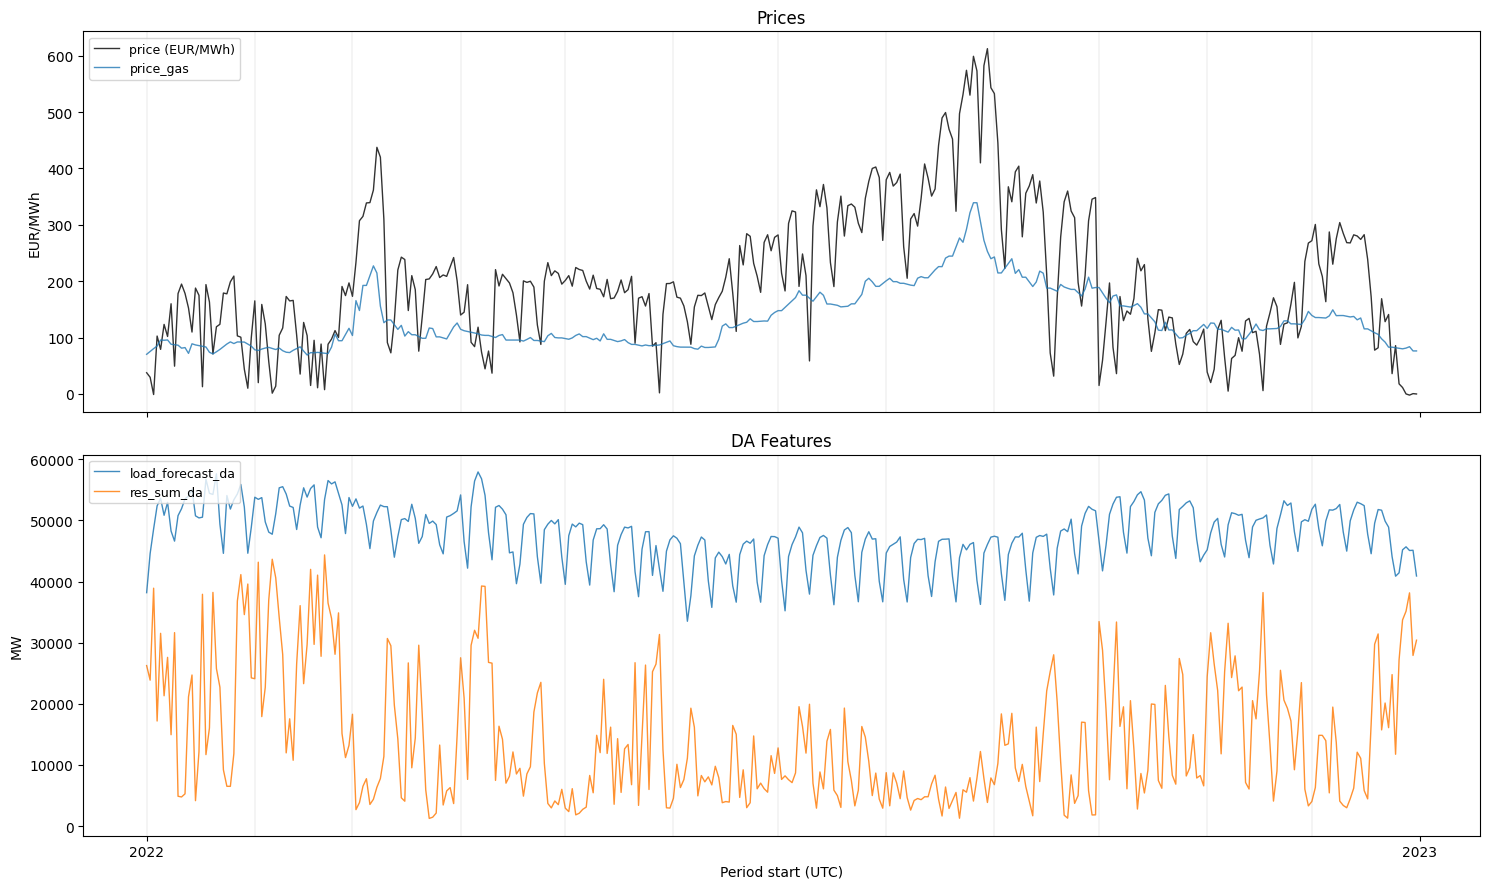

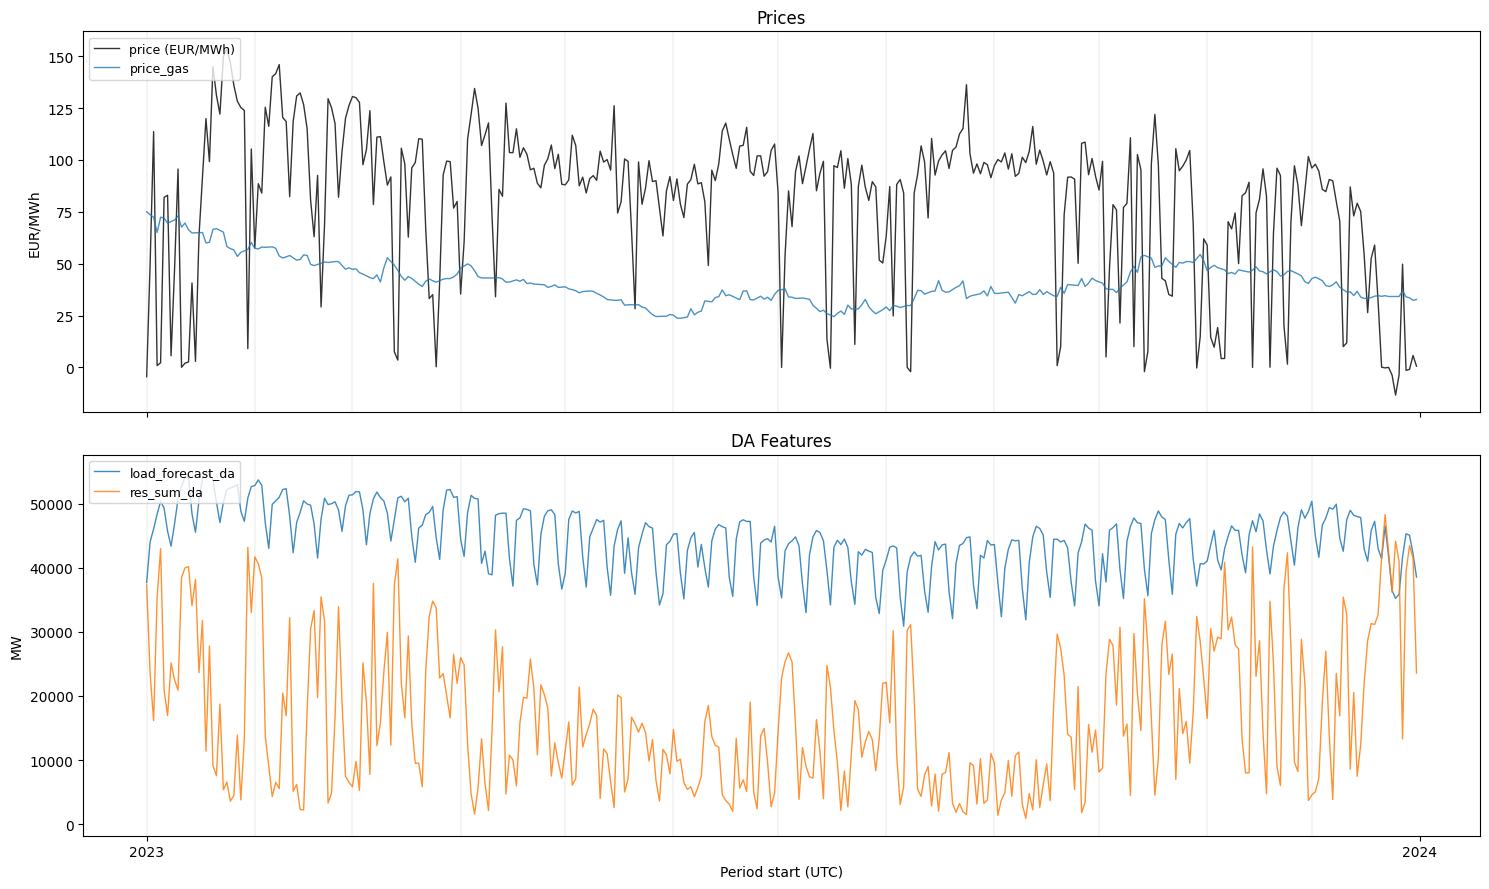

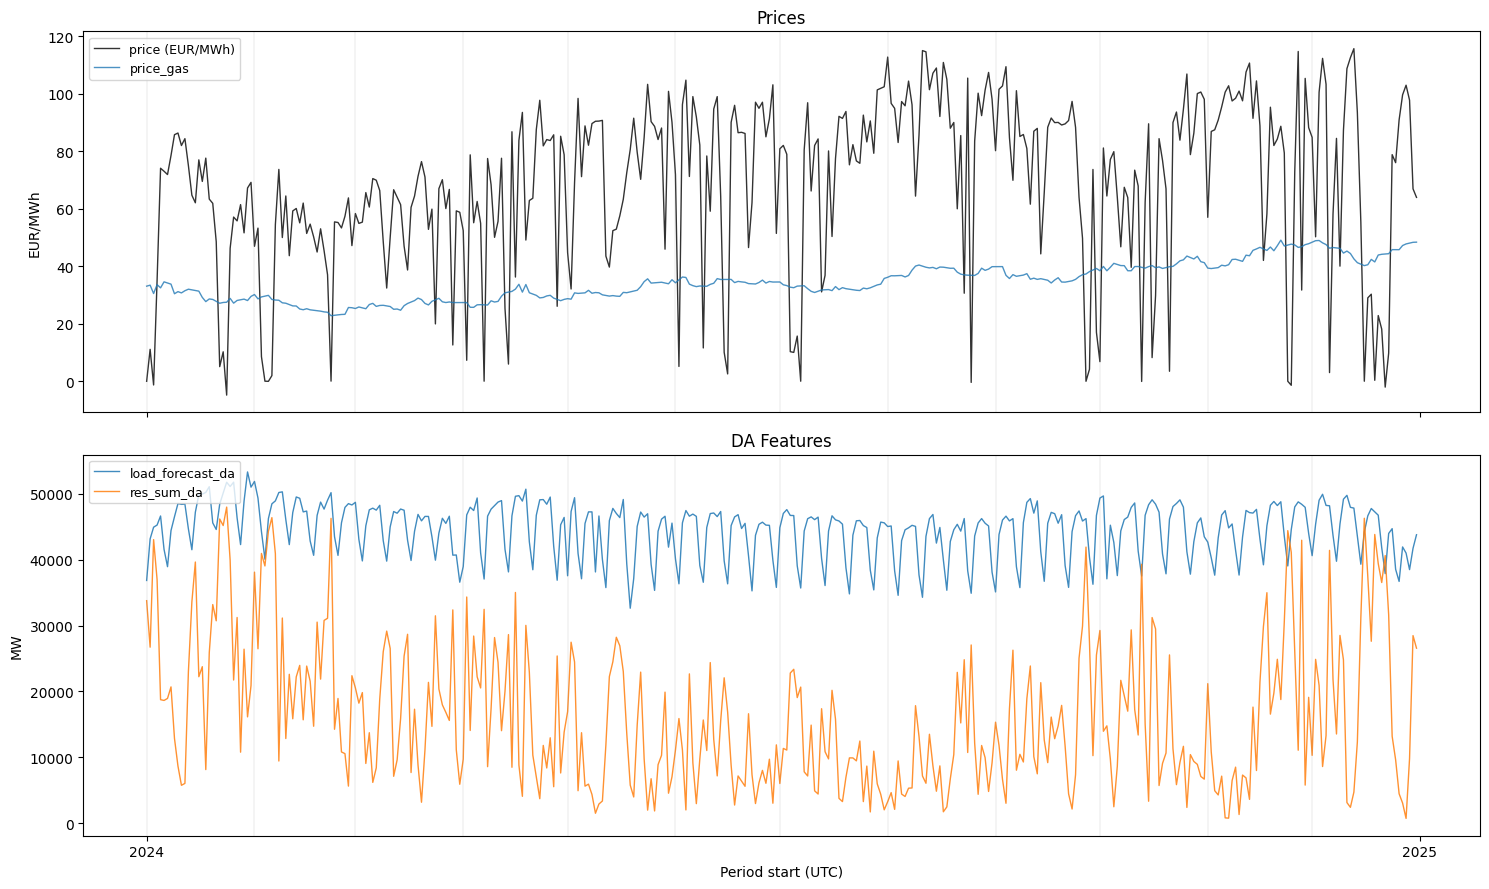

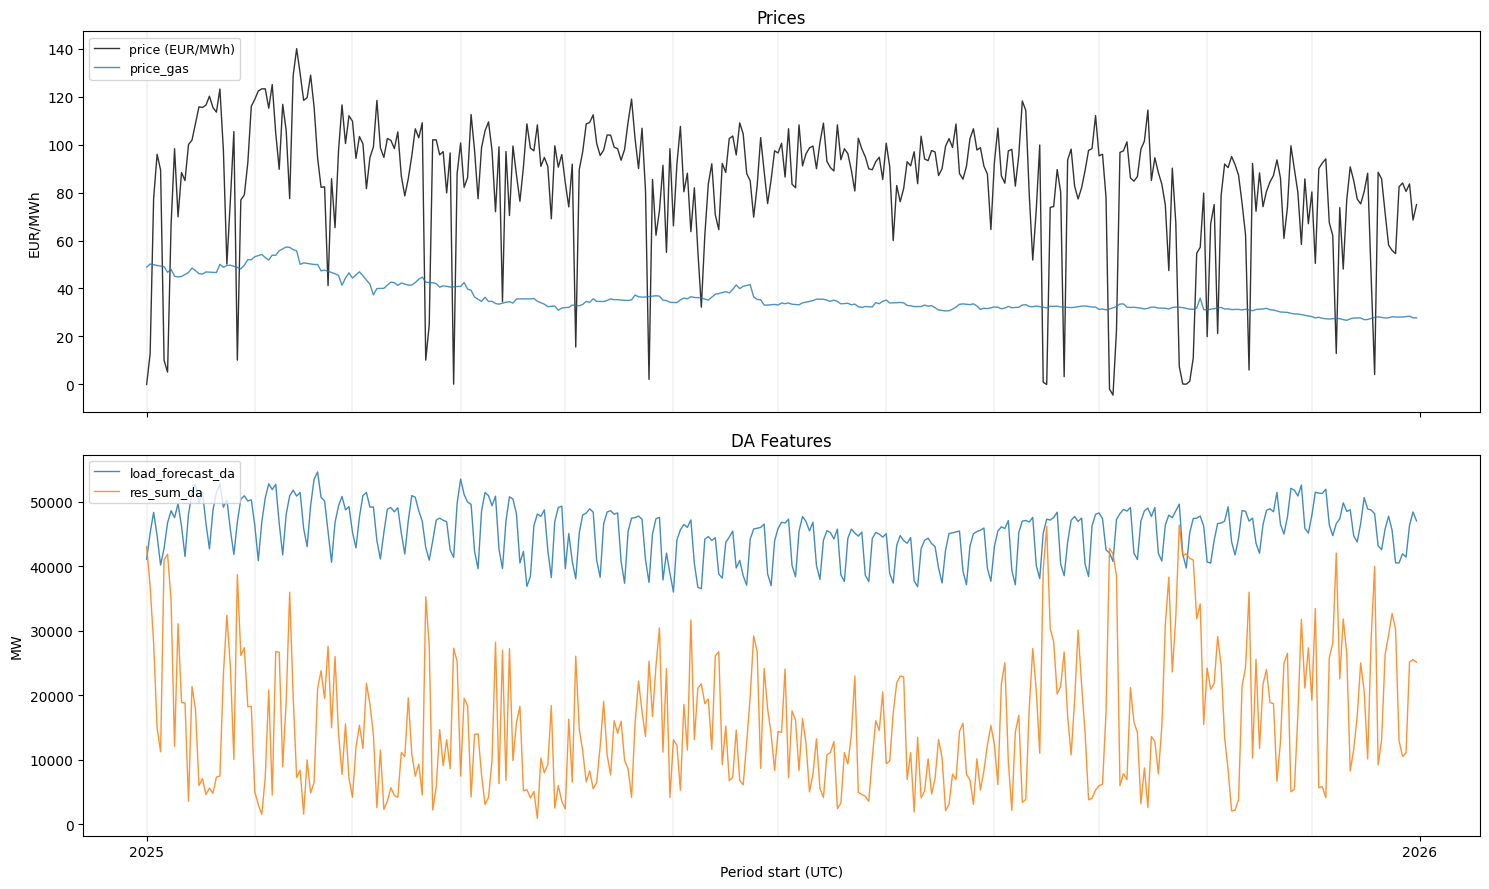

,period_start_utc,price,price_gas,load_forecast_da,res_sum_da
0,2025-01-01 00:00:00+00:00,-0.0100,48.8890,41086.0000,43027.5400
1,2025-01-02 00:00:00+00:00,12.7500,50.2150,45143.7450,36878.1775
2,2025-01-03 00:00:00+00:00,77.5000,49.9050,48342.3825,28117.5500
3,2025-01-04 00:00:00+00:00,95.9500,49.6220,44725.1725,14913.3000
4,2025-01-05 00:00:00+00:00,89.3800,49.3610,40176.8300,11231.4800
...,...,...,...,...,...
360,2025-12-27 00:00:00+00:00,83.9975,28.0950,41917.3900,10518.4750
361,2025-12-28 00:00:00+00:00,80.4475,28.2725,41403.8875,11084.2175
362,2025-12-29 00:00:00+00:00,83.6225,28.4500,46316.0975,25167.3675
363,2025-12-30 00:00:00+00:00,68.5375,27.7660,48397.1025,25520.0100


In [6]:
plot_prices_and_da_features(df)
plot_prices_and_da_features(df, years=[2019])
plot_prices_and_da_features(df, years=[2020])
plot_prices_and_da_features(df, years=[2021])
plot_prices_and_da_features(df, years=[2022])
plot_prices_and_da_features(df, years=[2023])
plot_prices_and_da_features(df, years=[2024])
plot_prices_and_da_features(df, years=[2025])
# plot_prices_and_da_features(df, feature_cols_da=["load_forecast_da"])


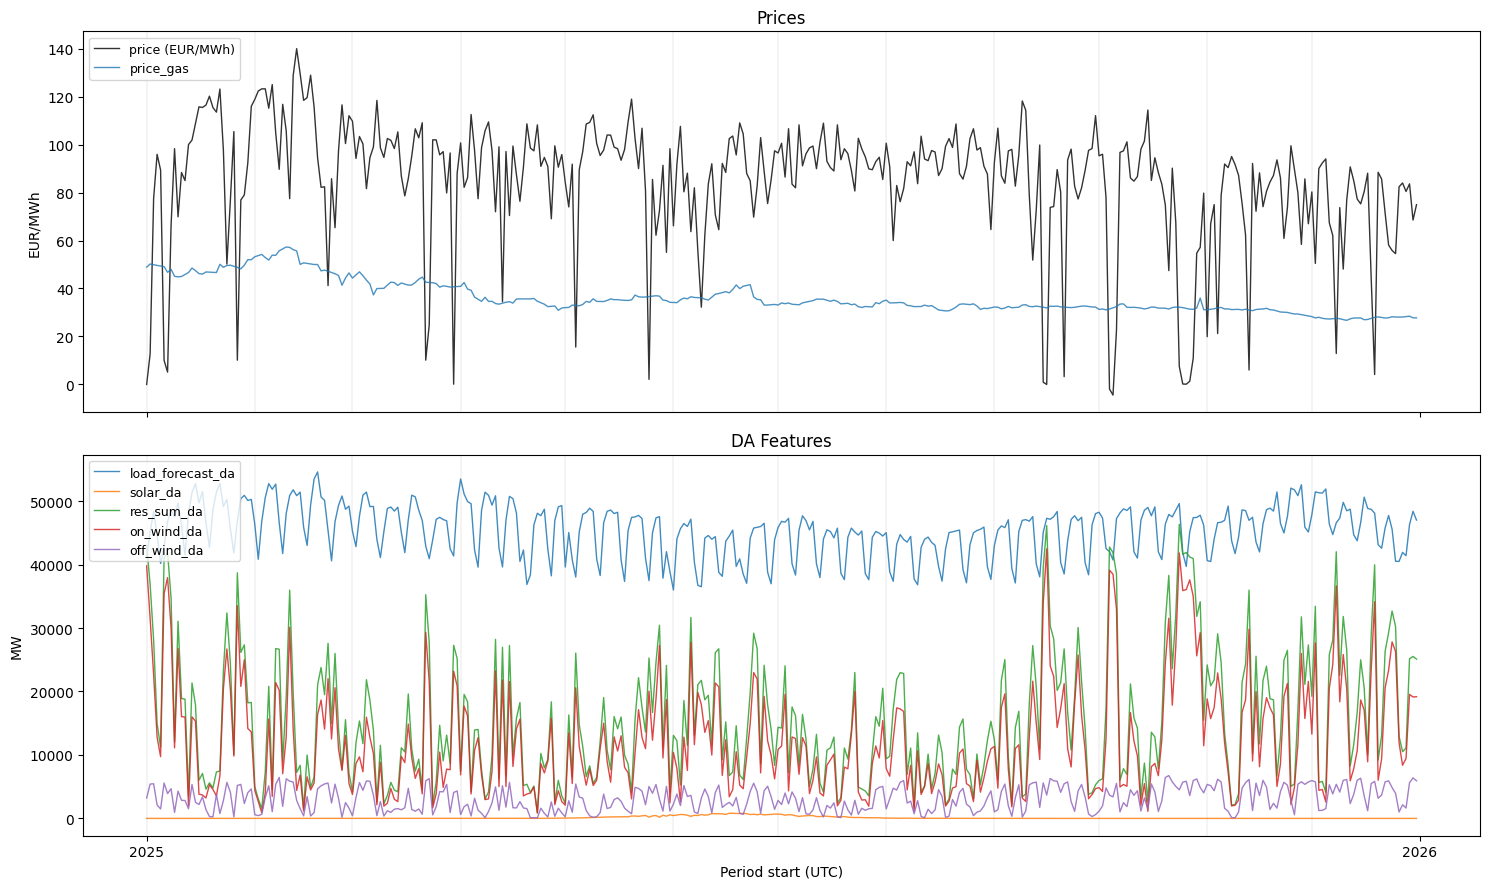

,period_start_utc,price,price_gas,load_forecast_da,solar_da,res_sum_da,on_wind_da,off_wind_da
0,2025-01-01 00:00:00+00:00,-0.0100,48.8890,41086.0000,0.0,43027.5400,39813.9475,3213.5925
1,2025-01-02 00:00:00+00:00,12.7500,50.2150,45143.7450,0.0,36878.1775,31475.2375,5402.9400
2,2025-01-03 00:00:00+00:00,77.5000,49.9050,48342.3825,0.0,28117.5500,22654.8225,5462.7275
3,2025-01-04 00:00:00+00:00,95.9500,49.6220,44725.1725,0.0,14913.3000,12811.7750,2101.5250
4,2025-01-05 00:00:00+00:00,89.3800,49.3610,40176.8300,0.0,11231.4800,9732.2700,1499.2100
...,...,...,...,...,...,...,...,...
360,2025-12-27 00:00:00+00:00,83.9975,28.0950,41917.3900,0.0,10518.4750,8379.3275,2139.1475
361,2025-12-28 00:00:00+00:00,80.4475,28.2725,41403.8875,0.0,11084.2175,9450.8250,1633.3925
362,2025-12-29 00:00:00+00:00,83.6225,28.4500,46316.0975,0.0,25167.3675,19541.1950,5626.1725
363,2025-12-30 00:00:00+00:00,68.5375,27.7660,48397.1025,0.0,25520.0100,19136.1000,6383.9100


In [8]:
# plot_prices_and_da_features(df)
# plot_prices_and_da_features(df, years=[2019])
# plot_prices_and_da_features(df, years=[2020])
# plot_prices_and_da_features(df, years=[2021])
# plot_prices_and_da_features(df, years=[2022])
# plot_prices_and_da_features(df, years=[2023])
# plot_prices_and_da_features(df, years=[2024])
plot_prices_and_da_features(df, years=[2025], feature_cols_da=["load_forecast_da", "solar_da","res_sum_da", "on_wind_da","off_wind_da"])
# plot_prices_and_da_features(df, feature_cols_da=["load_forecast_da"])